In [1]:
# Standard libraries
import os
# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [5]:
path = "../../data/processed/"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)

In [6]:
# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# index SamplingOperations_code
df = df.set_index('SamplingOperations_code')
 
# DROP HERlvl2Code	Altitude Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code
df = df.drop(columns=['HERlvl2Code', 'HERlvl2Name', 'HERlvl1Name', 'Altitude','Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement', 'CodeSite_SamplingOperations', 'Date_SamplingOperation'])
df

TotalAbundance_SamplingOperation  Achaa01  Achac01  \
SamplingOperations_code                                                       
S02000008_20170703                                    405      NaN      NaN   
S02000008_20200708                                    400      NaN      NaN   
S02000010_20070906                                    400      NaN      NaN   
S02000010_20090721                                    400      NaN      NaN   
S02000010_20110723                                    398      NaN      NaN   
...                                                   ...      ...      ...   
S06940940_20100708                                    438      NaN      NaN   
S06940940_20230623                                    408      NaN      NaN   
S06960950_20160629                                    401      NaN      NaN   
S06960950_20180719                                    416      NaN      NaN   
S06970900_20150601                                    432      NaN      NaN   

                         Achaf01    Achaf02  Achal01  Acham01  Achan01  \
SamplingOperations_code                                                  
S02000008_20170703           NaN        NaN      NaN      NaN      NaN   
S02000008_20200708           NaN        NaN      NaN      NaN      NaN   
S02000010_20070906           NaN        NaN      NaN      NaN      NaN   
S02000010_20090721           NaN        NaN      NaN      NaN      NaN   
S02000010_20110723           NaN        NaN      NaN      NaN      NaN   
...                          ...        ...      ...      ...      ...   
S06940940_20100708           NaN        NaN      NaN      NaN      NaN   
S06940940_20230623           NaN        NaN      NaN      NaN      NaN   
S06960950_20160629           NaN        NaN      NaN      NaN      NaN   
S06960950_20180719           NaN  19.230769      NaN      NaN      NaN   
S06970900_20150601           NaN        NaN      NaN      NaN      NaN   

                         Achat01   Achat02  Achat03  Achba01  Achbi01  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN       NaN      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN  6.944444      NaN      NaN      NaN   

                         Achbi02   Achbr01  Achca01  Achca02  Achca03  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN  2.283105      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN       NaN      NaN      NaN      NaN   

                         Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
SamplingOperations_code                              

# For each region

In [8]:
import cleandf

In [9]:
# For all regions 1, 2, ..., 22
regiondfs = {}
for region in range(1, 23):
    print(f"Region: {region}")
    regiondf = df[df['HERlvl1Code'] == region]

    cleanregion = cleandf.IWANTMYXCLEAN(regiondf)
    regiondfs[region] = cleanregion

Region: 1
Dropped exact duplicate columns: ['Achac01', 'Achal01', 'Achca01', 'Achch01', 'Achcl01', 'Achco01', 'Achco03', 'Achcy01', 'Achde01', 'Achde02', 'Achdi01', 'Achdi02', 'Achel01', 'Achen01', 'Achex03', 'Achfl01', 'Achfr01', 'Achgr01', 'Achgr02', 'Achha01', 'Achhe01', 'Achhi01', 'Achho01', 'Achho02', 'Achim01', 'Achim02', 'Achim03', 'Achin01', 'Achin02', 'Achjo01', 'Achko01', 'Achkr01', 'Achkr03', 'Achkr04', 'Achku01', 'Achla01', 'Achla05', 'Achle01', 'Achle02', 'Achli02', 'Achli04', 'Achlo01', 'Achlu01', 'Achlu02', 'Achmo01', 'Achmo02', 'Achna01', 'Achna02', 'Achni01', 'Achno01', 'Achpa01', 'Achpe01', 'Achpe02', 'Achpl01', 'Achpo01', 'Achpr01', 'Achpr02', 'Achps01', 'Achps02', 'Achps03', 'Achpu01', 'Achro01', 'Achro03', 'Achru02', 'Achsc01', 'Achse01', 'Achse02', 'Achsi01', 'Achst01', 'Achst02', 'Achst04', 'Achsu02', 'Achsu04', 'Achtu01', 'Achzi01', 'Actde01', 'Actno01', 'Actro01', 'Actse01', 'Actsp01', 'Actsu01', 'Actvu01', 'Adlaq01', 'Adlbr01', 'Adlmu01', 'Adlmu02', 'Adlpa01',

In [12]:
regiondfs[1]

,TotalAbundance_SamplingOperation,Achaf02,Achat02,Achde03,Acheu01,Achho03,Achla02,Achli03,Achmi02,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampin02,Amppe02,Calae01,Coceu01,Cocli01,Cocpe01,Cocpl01,Cymco01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diaeh01,Diame01,Diavu01,Exiva01,Fragr01,Frape01,Geiac01,Goman05,Gomel01,Gomex01,Gomin06,Gommi01,Gommi05,Gomol04,Gompa06,Gompu02,Gomrh01,Gomte02,Hanar01,Melva01,Navan05,Navar02,Navca07,Navcr05,Navcr09,Navgr01,Navpe05,Navre04,Navsa03,Navsu03,Navsu07,Nitar01,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitpa01,Nitpa02,Nitso01,Nitso04,Plala02,Reisi01,Reiun01,Rhoab01,Selni01,Synde01,Synul01,Vibtr01,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S05168100_20070809,400,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,80.000000,682.500000,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,15.000000,70.000000,NaN,NaN,5.0,NaN,NaN,27.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.5,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,High,High,NaN,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20080806,400,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,25.000000,765.000000,15.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,2.500000,10.000000,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,2.500000,2.5,NaN,NaN,NaN,NaN,7.5,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,NaN,NaN,NaN,NaN,NaN,20.0,1.0,High,7.500000,1
S05168100_20090625,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,637.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,5.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162.5,NaN,NaN,NaN,NaN,12.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,Good,High,High,High,High,High,High,High,High,High,Moderate,Moderate,Moderate,Bad,Bad,Bad,High,High,High,Good,Good,Good,Moderate,Moderate,Moderate,20.0,1.0,High,22.500000,1
S05168100_20100629,414,NaN,24.154589,NaN,NaN,NaN,NaN,NaN,36.231884,826.086957,NaN,NaN,38.647343,NaN,NaN,NaN,NaN,NaN,NaN,7.246377,NaN,NaN,NaN,NaN,4.830918,33.816425,NaN,NaN,NaN,NaN,NaN,NaN,9.661836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.415459,NaN,NaN,4.830918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.830918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.415459,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,NaN,NaN,High,NaN,NaN,High,NaN,NaN,High,NaN,NaN,Moderate,NaN,NaN,Bad,NaN,NaN,High,NaN,NaN,Moderate,NaN,NaN,Poor,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20110809,400,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,90.000000,692.500000,22.5,NaN,22.500000,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,7.500000,22.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,N

In [22]:
# === imports
from typing import Dict, Any, List, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor


class MultiRegionRF:
    """
    Train one RandomForestRegressor per region using all rows with non-NaN target,
    then infer the target for rows with NaN target.
    """

    def __init__(self, xcleans: Dict[Any, pd.DataFrame], random_state: int = 42):
        # xcleans: {region_id -> cleaned DataFrame that contains both labeled and unlabeled rows}
        self.xcleans = xcleans
        self.random_state = random_state
        self.results: Dict[Any, Dict[str, Any]] = {}
        self.target_column: Optional[str] = None

    @staticmethod
    def _build_preprocessor(X: pd.DataFrame) -> tuple[ColumnTransformer, List[str], List[str]]:
        num_cols = X.select_dtypes(include=["number"]).columns.tolist()
        cat_cols = [c for c in X.columns if c not in num_cols]
        pre = ColumnTransformer(
            transformers=[
                ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
                ("cat", Pipeline([
                    ("imp", SimpleImputer(strategy="constant", fill_value="None")),
                    # use dense output for easy feature importance mapping
                    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]), cat_cols),
            ],
            remainder="drop",
        )
        return pre, num_cols, cat_cols

    @staticmethod
    def _feature_names_from_pre(pre: ColumnTransformer, num_cols: List[str], cat_cols: List[str]) -> List[str]:
        names: List[str] = []
        if num_cols:
            names.extend(num_cols)
        if cat_cols and "cat" in pre.named_transformers_:
            ohe = pre.named_transformers_["cat"].named_steps["ohe"]
            names.extend(ohe.get_feature_names_out(cat_cols).tolist())
        return names

    def process_missing(
        self,
        target_column: str,
        n_estimators: int = 500,
        max_depth: Optional[int] = None,
        min_samples_leaf: int = 1,
        n_jobs: int = -1,
        verbose: bool = True,
    ):
        """
        For each region DF:
          - Train on rows where target is not NaN
          - Predict target for rows where target is NaN
          - Store OOB R^2 as a quality proxy (no y_test available)
        """
        self.results.clear()
        self.target_column = target_column

        for key, Xclean in self.xcleans.items():
            if target_column not in Xclean.columns:
                if verbose: print(f"[skip {key}] missing target '{target_column}'")
                continue
            if len(Xclean) < 5:
                if verbose: print(f"[skip {key}] too few rows: {len(Xclean)}")
                continue

            # y and X
            y = Xclean[target_column]
            drop_cols = [c for c in [target_column, f"{target_column}_EQR", f"{target_column}_EQR_Status"] if c in Xclean.columns]
            X = Xclean.drop(columns=drop_cols, errors="ignore")

            # masks
            mask_tr = y.notna()
            mask_te = ~mask_tr
            n_tr, n_te = int(mask_tr.sum()), int(mask_te.sum())
            if n_tr == 0:
                if verbose: print(f"[skip {key}] no labeled rows")
                continue

            # preprocessor + model
            pre, num_cols, cat_cols = self._build_preprocessor(X)
            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=self.random_state,
                n_jobs=n_jobs,
                bootstrap=True,
                oob_score=True,   # quality proxy without holdout labels
            )
            pipe = Pipeline([("pre", pre), ("model", rf)])

            # fit
            X_tr, y_tr = X.loc[mask_tr], y.loc[mask_tr]
            pipe.fit(X_tr, y_tr)

            # predictions
            yhat_tr = pd.Series(pipe.predict(X_tr), index=y_tr.index, name="yhat_tr")
            if n_te:
                X_te = X.loc[mask_te]
                yhat_te = pd.Series(pipe.predict(X_te), index=X_te.index, name="yhat_te")
            else:
                X_te = X.iloc[0:0]  # empty
                yhat_te = pd.Series(dtype=float, name="yhat_te")

            # feature importance on fitted preprocessor
            pre_fitted = pipe.named_steps["pre"]
            feat_names = self._feature_names_from_pre(pre_fitted, num_cols, cat_cols)
            model = pipe.named_steps["model"]
            fi = pd.Series(model.feature_importances_, index=feat_names).sort_values(ascending=False)

            # imputed target vector for the whole DF
            y_filled = y.copy()
            if n_te:
                y_filled.loc[mask_te] = yhat_te.values

            # store
            self.results[key] = {
                "model": pipe,
                "oob_r2": getattr(model, "oob_score_", None),
                "n_train": n_tr,
                "n_infer": n_te,
                "y_tr": y_tr,
                "yhat_tr": yhat_tr,
                "X_te_index": X_te.index,
                "yhat_te": yhat_te,
                "y_filled": y_filled,
                "feature_importances": fi,
                "columns": {"num": num_cols, "cat": cat_cols},
            }
            if verbose:
                oob = self.results[key]["oob_r2"]
                oob_str = f"{oob:.3f}" if oob is not None else "NA"
                print(f"[done {key}] train={n_tr} infer={n_te} oob_r2={oob_str}")

    # -------- convenience accessors --------

    def infer_table(self, key: Any) -> pd.DataFrame:
        """Return a table indexed by original rows for that region."""
        r = self.results[key]
        out = pd.DataFrame(index=self.xcleans[key].index)
        out["y_true"] = r["y_tr"]            # NaN for unlabeled rows automatically
        out["yhat_tr"] = r["yhat_tr"]
        out["yhat_te"] = r["yhat_te"]
        out["y_filled"] = r["y_filled"]
        return out

    def all_inferred(self) -> pd.DataFrame:
        """Concatenate all regions with row_id and region columns."""
        frames = []
        for k, r in self.results.items():
            df = pd.DataFrame(index=self.xcleans[k].index)
            df["y_true"] = r["y_tr"]
            df["yhat_tr"] = r["yhat_tr"]
            df["yhat_te"] = r["yhat_te"]
            df["y_filled"] = r["y_filled"]
            df = df.reset_index().rename(columns={"index": "row_id"})
            df.insert(0, "region", k)
            frames.append(df)
        return pd.concat(frames, ignore_index=True)

    def filled_dataframe(self, key: Any) -> pd.DataFrame:
        """Return a copy of the region DF with target filled in missing rows."""
        if self.target_column is None:
            raise RuntimeError("Run process_missing first.")
        df = self.xcleans[key].copy()
        df[self.target_column] = self.results[key]["y_filled"]
        return df

    def top_features(self, key: Any, k: int = 20) -> pd.DataFrame:
        fi = self.results[key]["feature_importances"]
        return fi.head(k).reset_index().rename(columns={"index": "feature", 0: "importance"})

    def plot_parity_train(self, key: Any, title: Optional[str] = None):
        r = self.results[key]
        y, yhat = r["y_tr"], r["yhat_tr"]
        plt.figure(figsize=(6, 6))
        plt.scatter(y, yhat, alpha=0.5, edgecolor="k")
        lo, hi = float(min(y.min(), yhat.min())), float(max(y.max(), yhat.max()))
        plt.plot([lo, hi], [lo, hi], "r--", lw=2)
        plt.title(title or f"Train parity — region {key}")
        plt.xlabel("y_true"); plt.ylabel("yhat_tr"); plt.grid(True); plt.tight_layout(); plt.show()

    def predict_new(self, key: Any, X_new: pd.DataFrame) -> np.ndarray:
        """Predict on new rows using the region's fitted pipeline."""
        return self.results[key]["model"].predict(X_new)


In [23]:
mr = MultiRegionRF(regiondfs, random_state=42)
mr.process_missing(target_column="IBD", n_estimators=500, max_depth=None, min_samples_leaf=1, n_jobs=-1)

[done 1] train=1313 infer=172 oob_r2=0.732
[done 2] train=308 infer=44 oob_r2=0.800
[done 3] train=4430 infer=566 oob_r2=0.865
[done 4] train=494 infer=102 oob_r2=0.796
[done 5] train=2069 infer=244 oob_r2=0.904
[done 6] train=1898 infer=236 oob_r2=0.879
[done 7] train=466 infer=58 oob_r2=0.880
[done 8] train=469 infer=79 oob_r2=0.713
[done 9] train=9136 infer=1118 oob_r2=0.829
[done 10] train=3389 infer=537 oob_r2=0.892
[done 11] train=1141 infer=148 oob_r2=0.833
[done 12] train=4188 infer=489 oob_r2=0.856
[done 13] train=888 infer=115 oob_r2=0.798
[done 14] train=6916 infer=826 oob_r2=0.856
[done 15] train=1099 infer=124 oob_r2=0.844
[done 16] train=331 infer=48 oob_r2=0.744
[done 17] train=716 infer=87 oob_r2=0.811
[done 18] train=977 infer=187 oob_r2=0.794
[done 19] train=440 infer=60 oob_r2=0.707
[done 20] train=448 infer=60 oob_r2=0.772
[done 21] train=2332 infer=331 oob_r2=0.846
[done 22] train=120 infer=32 oob_r2=0.612


In [25]:
tbl1 = mr.infer_table(1)           # columns: y_true, yhat_tr, yhat_te, y_filled
tbl1

,y_true,yhat_tr,yhat_te,y_filled
SamplingOperations_code,,,,
S05168100_20070809,20.0,20.0,NaN,20.0000
S05168100_20080806,20.0,20.0,NaN,20.0000
S05168100_20090625,20.0,20.0,NaN,20.0000
S05168100_20100629,20.0,20.0,NaN,20.0000
S05168100_20110809,20.0,20.0,NaN,20.0000
...,...,...,...,...
S06175540_20150728,NaN,NaN,19.9788,19.9788
S06175600_20170904,NaN,NaN,19.9226,19.9226
S06175600_20180926,NaN,NaN,18.6130,18.6130


In [26]:
df1_filled = mr.filled_dataframe(1)
df1_filled

,TotalAbundance_SamplingOperation,Achaf02,Achat02,Achde03,Acheu01,Achho03,Achla02,Achli03,Achmi02,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampin02,Amppe02,Calae01,Coceu01,Cocli01,Cocpe01,Cocpl01,Cymco01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diaeh01,Diame01,Diavu01,Exiva01,Fragr01,Frape01,Geiac01,Goman05,Gomel01,Gomex01,Gomin06,Gommi01,Gommi05,Gomol04,Gompa06,Gompu02,Gomrh01,Gomte02,Hanar01,Melva01,Navan05,Navar02,Navca07,Navcr05,Navcr09,Navgr01,Navpe05,Navre04,Navsa03,Navsu03,Navsu07,Nitar01,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitpa01,Nitpa02,Nitso01,Nitso04,Plala02,Reisi01,Reiun01,Rhoab01,Selni01,Synde01,Synul01,Vibtr01,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S05168100_20070809,400,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,80.000000,682.500000,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,15.000000,70.000000,NaN,NaN,5.0,NaN,NaN,27.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.5,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,High,High,NaN,NaN,NaN,20.0000,1.0,High,0.000000,1
S05168100_20080806,400,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,25.000000,765.000000,15.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,2.500000,10.000000,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,2.500000,2.5,NaN,NaN,NaN,NaN,7.5,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,NaN,NaN,NaN,NaN,NaN,20.0000,1.0,High,7.500000,1
S05168100_20090625,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,637.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,5.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162.5,NaN,NaN,NaN,NaN,12.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,Good,High,High,High,High,High,High,High,High,High,Moderate,Moderate,Moderate,Bad,Bad,Bad,High,High,High,Good,Good,Good,Moderate,Moderate,Moderate,20.0000,1.0,High,22.500000,1
S05168100_20100629,414,NaN,24.154589,NaN,NaN,NaN,NaN,NaN,36.231884,826.086957,NaN,NaN,38.647343,NaN,NaN,NaN,NaN,NaN,NaN,7.246377,NaN,NaN,NaN,NaN,4.830918,33.816425,NaN,NaN,NaN,NaN,NaN,NaN,9.661836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.415459,NaN,NaN,4.830918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.830918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.415459,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,NaN,NaN,High,NaN,NaN,High,NaN,NaN,High,NaN,NaN,Moderate,NaN,NaN,Bad,NaN,NaN,High,NaN,NaN,Moderate,NaN,NaN,Poor,NaN,NaN,20.0000,1.0,High,0.000000,1
S05168100_20110809,400,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,90.000000,692.500000,22.5,NaN,22.500000,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,7.500000,22.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,NaN,NaN,NaN,NaN,10.0,N

In [31]:
all_preds = mr.all_inferred()
all_preds = all_preds.set_index('SamplingOperations_code')
all_preds

,region,y_true,yhat_tr,yhat_te,y_filled
SamplingOperations_code,,,,,
S05168100_20070809,1,20.0,20.0,NaN,20.0000
S05168100_20080806,1,20.0,20.0,NaN,20.0000
S05168100_20090625,1,20.0,20.0,NaN,20.0000
S05168100_20100629,1,20.0,20.0,NaN,20.0000
S05168100_20110809,1,20.0,20.0,NaN,20.0000
...,...,...,...,...,...
S03128500_20120723,22,NaN,NaN,13.4662,13.4662
S03128640_20130718,22,NaN,NaN,13.0850,13.0850
S03128640_20181011,22,NaN,NaN,13.0650,13.0650


In [ ]:
mr.results[1]["oob_r2"]

0.7324583333601042

In [29]:
mr.top_features(1, k=15)

,feature,importance
0,Achpy01,0.274825
1,Navcr09,0.184145
2,Navpe05,0.079526
3,Achmi02,0.052609
4,Nitpa02,0.044950
5,Coceu01,0.024677
6,Nitfo01,0.024464
7,Selni01,0.018935
8,Uncommon_Taxons,0.016254
9,Gommi05,0.014589


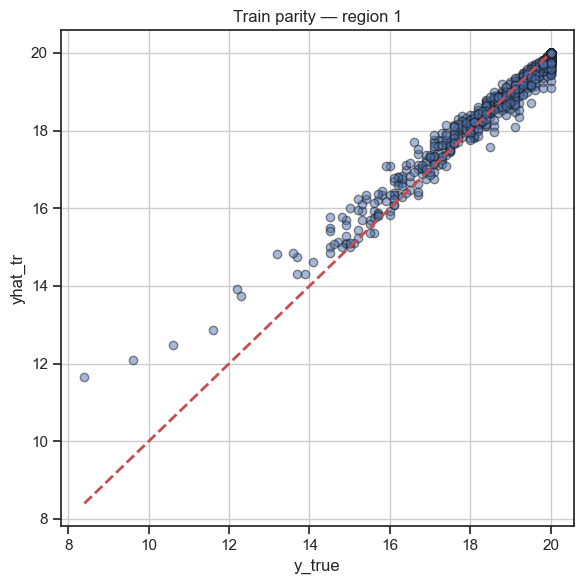

In [30]:
mr.plot_parity_train(1)

# Get status

In [ ]:
ranges = pd.read_csv("../../data/processed/ibd_eqr_ranges_by_herlvl1_continuous_midpoint.csv")
COMPLETE_TRAIN = pd.read_parquet(os.path.join(path, "03_COMPLETE_TRAIN.parquet"))
yhat_te = all_preds['yhat_te'][all_preds['yhat_te'].notna()]

SamplingOperations_code
S05169000_20130911    19.9850
S05169000_20200819    19.2216
S05172000_20210813    18.2772
S05172050_20210824    17.3672
S05172350_20120827    19.9650
                       ...   
S03128500_20120723    13.4662
S03128640_20130718    13.0850
S03128640_20181011    13.0650
S03128732_20210817    12.6820
S03129170_20150630    19.7278
Name: yhat_te, Length: 5663, dtype: float64

In [64]:
# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)
df = df.set_index('SamplingOperations_code')
df

CodeSite_SamplingOperations Date_SamplingOperation  \
SamplingOperations_code                                                      
S02000008_20170703                        S02000008             2017-07-03   
S02000008_20200708                        S02000008             2020-07-08   
S02000010_20070906                        S02000010             2007-09-06   
S02000010_20090721                        S02000010             2009-07-21   
S02000010_20110723                        S02000010             2011-07-23   
...                                             ...                    ...   
S06940940_20100708                        S06940940             2010-07-08   
S06940940_20230623                        S06940940             2023-06-23   
S06960950_20160629                        S06960950             2016-06-29   
S06960950_20180719                        S06960950             2018-07-19   
S06970900_20150601                        S06970900             2015-06-01   

                         TotalAbundance_SamplingOperation  Achaa01  Achac01  \
SamplingOperations_code                                                       
S02000008_20170703                                    405      NaN      NaN   
S02000008_20200708                                    400      NaN      NaN   
S02000010_20070906                                    400      NaN      NaN   
S02000010_20090721                                    400      NaN      NaN   
S02000010_20110723                                    398      NaN      NaN   
...                                                   ...      ...      ...   
S06940940_20100708                                    438      NaN      NaN   
S06940940_20230623                                    408      NaN      NaN   
S06960950_20160629                                    401      NaN      NaN   
S06960950_20180719                                    416      NaN      NaN   
S06970900_20150601                                    432      NaN      NaN   

                         Achaf01    Achaf02  Achal01  Acham01  Achan01  \
SamplingOperations_code                                                  
S02000008_20170703           NaN        NaN      NaN      NaN      NaN   
S02000008_20200708           NaN        NaN      NaN      NaN      NaN   
S02000010_20070906           NaN        NaN      NaN      NaN      NaN   
S02000010_20090721           NaN        NaN      NaN      NaN      NaN   
S02000010_20110723           NaN        NaN      NaN      NaN      NaN   
...                          ...        ...      ...      ...      ...   
S06940940_20100708           NaN        NaN      NaN      NaN      NaN   
S06940940_20230623           NaN        NaN      NaN      NaN      NaN   
S06960950_20160629           NaN        NaN      NaN      NaN      NaN   
S06960950_20180719           NaN  19.230769      NaN      NaN      NaN   
S06970900_20150601           NaN        NaN      NaN      NaN      NaN   

                         Achat01   Achat02  Achat03  Achba01  Achbi01  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN       NaN      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN  6.944444      NaN      NaN      NaN   

                         Achbi02   Achbr01  Achca01  Achca02  Achca0

In [55]:
# rename yhat_te to IBD_Predicted
yhat = yhat_te.rename("IBD_Predicted")
yhat = yhat.to_frame()
yhat

,IBD_Predicted
SamplingOperations_code,
S05169000_20130911,19.9850
S05169000_20200819,19.2216
S05172000_20210813,18.2772
S05172050_20210824,17.3672
S05172350_20120827,19.9650
...,...
S03128500_20120723,13.4662
S03128640_20130718,13.0850
S03128640_20181011,13.0650


In [65]:
names = df.loc[yhat_te.index, ['HERlvl1Name']]
names

,HERlvl1Name
SamplingOperations_code,
S05169000_20130911,PYRENEES
S05169000_20200819,PYRENEES
S05172000_20210813,PYRENEES
S05172050_20210824,PYRENEES
S05172350_20120827,PYRENEES
...,...
S03128500_20120723,ARDENNES
S03128640_20130718,ARDENNES
S03128640_20181011,ARDENNES


In [66]:
yhat = pd.concat([yhat, names], axis=1)
yhat

,IBD_Predicted,HERlvl1Name
SamplingOperations_code,,
S05169000_20130911,19.9850,PYRENEES
S05169000_20200819,19.2216,PYRENEES
S05172000_20210813,18.2772,PYRENEES
S05172050_20210824,17.3672,PYRENEES
S05172350_20120827,19.9650,PYRENEES
...,...,...
S03128500_20120723,13.4662,ARDENNES
S03128640_20130718,13.0850,ARDENNES
S03128640_20181011,13.0650,ARDENNES


## mapping

In [ ]:
import mapping

In [ ]:
yhat2 = mapping.to_status(yhat, ranges)
yhat2

,IBD_Predicted,HERlvl1Name,IBD_EQR_Status_Predicted
SamplingOperations_code,,,
S05169000_20130911,19.9850,PYRENEES,High
S05169000_20200819,19.2216,PYRENEES,High
S05172000_20210813,18.2772,PYRENEES,Good
S05172050_20210824,17.3672,PYRENEES,Good
S05172350_20120827,19.9650,PYRENEES,High
...,...,...,...
S03128500_20120723,13.4662,ARDENNES,Moderate
S03128640_20130718,13.0850,ARDENNES,Moderate
S03128640_20181011,13.0650,ARDENNES,Moderate


In [89]:
send_predictions = mapping.get_results(yhat, ranges)
send_predictions

Saved predictions to IBD_EQR_Status_predictions_5663.csv


,IBD_EQR_Status
SamplingOperations_code,
S05169000_20130911,High
S05169000_20200819,High
S05172000_20210813,Good
S05172050_20210824,Good
S05172350_20120827,High
...,...
S03128500_20120723,Moderate
S03128640_20130718,Moderate
S03128640_20181011,Moderate


In [90]:
truesend = mapping.process_predictions(yhat, ranges)
truesend

Saved predictions to IBD_EQR_Status_predictions.csv


,IBD_EQR_Status
SamplingOperations_code,
S05169000_20130911,High
S05169000_20200819,High
S05172000_20210813,Good
S05172050_20210824,Good
S05172350_20120827,High
...,...
S03128220_20181011,Good
S03128500_20120723,Moderate
S03128640_20181011,Moderate


lol lol lol? nos deberia dar error?

al final toma en cuenta solo las 5063 predicciones que pide, no se que le hace a las otras 600